In [ ]:
import pandas as pd
from glob import glob
import os

# 1. Configuration and Paths

data_path = "../../data/raw/archive/A_DeviceMotion_data/A_DeviceMotion_data/"
subjects_info_path = "../../data/raw/archive/data_subjects_info.csv"

LABEL_MAP = {
    'dws': 0, 'ups': 1, 'wlk': 2, 'jog': 3, 'sit': 4, 'std': 5
}

files = glob(data_path + "*/*.csv")

# 2. Extract features from filename (Progressive Logic)

f = files[0]
folder_name = os.path.basename(os.path.dirname(f))
label = folder_name.split("_")[0]
category = folder_name.split("_")[1]
user_id = int(os.path.basename(f).replace("sub_", "").replace(".csv", ""))

# 3. Read and Combine all files

all_df = pd.DataFrame()
data_set = 1

for f in files:
    folder_name = os.path.basename(os.path.dirname(f))
    activity = folder_name.split("_")[0]
    trial = folder_name.split("_")[1]
    user_id = int(os.path.basename(f).replace("sub_", "").replace(".csv", ""))

    df = pd.read_csv(f)

    df["user_id"] = user_id
    df["label"] = LABEL_MAP[activity]
    df["category"] = activity
    df["set"] = data_set

    all_df = pd.concat([all_df, df], ignore_index=True)
    data_set += 1

# 4. Integration: Merge with Subject Information

df_subjects = pd.read_csv(subjects_info_path)
df_subjects = df_subjects.rename(columns={'code': 'user_id'})

all_df = pd.merge(all_df, df_subjects, on='user_id', how='left')

# 5. Cleaning and Renaming

if "Unnamed: 0" in all_df.columns:
    del all_df["Unnamed: 0"]

all_df.rename(columns={
    'userAcceleration.x': 'acc_x',
    'userAcceleration.y': 'acc_y',
    'userAcceleration.z': 'acc_z',
    'rotationRate.x': 'gyr_x',
    'rotationRate.y': 'gyr_y',
    'rotationRate.z': 'gyr_z'
}, inplace=True)

all_df.dropna(inplace=True)

# 6. Working with Datetimes (50Hz = 20ms)

all_df["time_ms"] = all_df.groupby("set").cumcount() * 20
all_df.index = pd.to_datetime(all_df["time_ms"], unit="ms")

# 7. Resampling (Rule: 200ms)

sampling = {
    "acc_x": "mean",
    "acc_y": "mean",
    "acc_z": "mean",
    "gyr_x": "mean",
    "gyr_y": "mean",
    "gyr_z": "mean",
    "label": "last",
    "category": "last",
    "user_id": "last",
    "set": "last",
    "weight": "last",
    "height": "last",
    "age": "last",
    "gender": "last"
}

data_resampled = (
    all_df
    .groupby(["user_id", "set"])
    .resample("200ms")
    .agg(sampling)
    .dropna()
)

data_resampled.reset_index(drop=True, inplace=True)

# 8. User-based Split (Train / Validation / Test)

users = sorted(data_resampled["user_id"].unique())

train_users = users[:18]
val_users = users[18:21]
test_users = users[21:]

train_df = data_resampled[data_resampled["user_id"].isin(train_users)]
val_df = data_resampled[data_resampled["user_id"].isin(val_users)]
test_df = data_resampled[data_resampled["user_id"].isin(test_users)]

assert set(train_users).isdisjoint(val_users)
assert set(train_users).isdisjoint(test_users)
assert set(val_users).isdisjoint(test_users)

# 9. Export Processed Data

output_dir = "../../data/processed/"
os.makedirs(output_dir, exist_ok=True)

data_resampled.to_pickle(os.path.join(output_dir, "data_processed.pkl"))
train_df.to_pickle(os.path.join(output_dir, "train.pkl"))
val_df.to_pickle(os.path.join(output_dir, "val.pkl"))
test_df.to_pickle(os.path.join(output_dir, "test.pkl"))

print("train users:", train_users)
print("val users:", val_users)
print("test users:", test_users)

train users: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
val users: [19, 20, 21]
test users: [22, 23, 24]


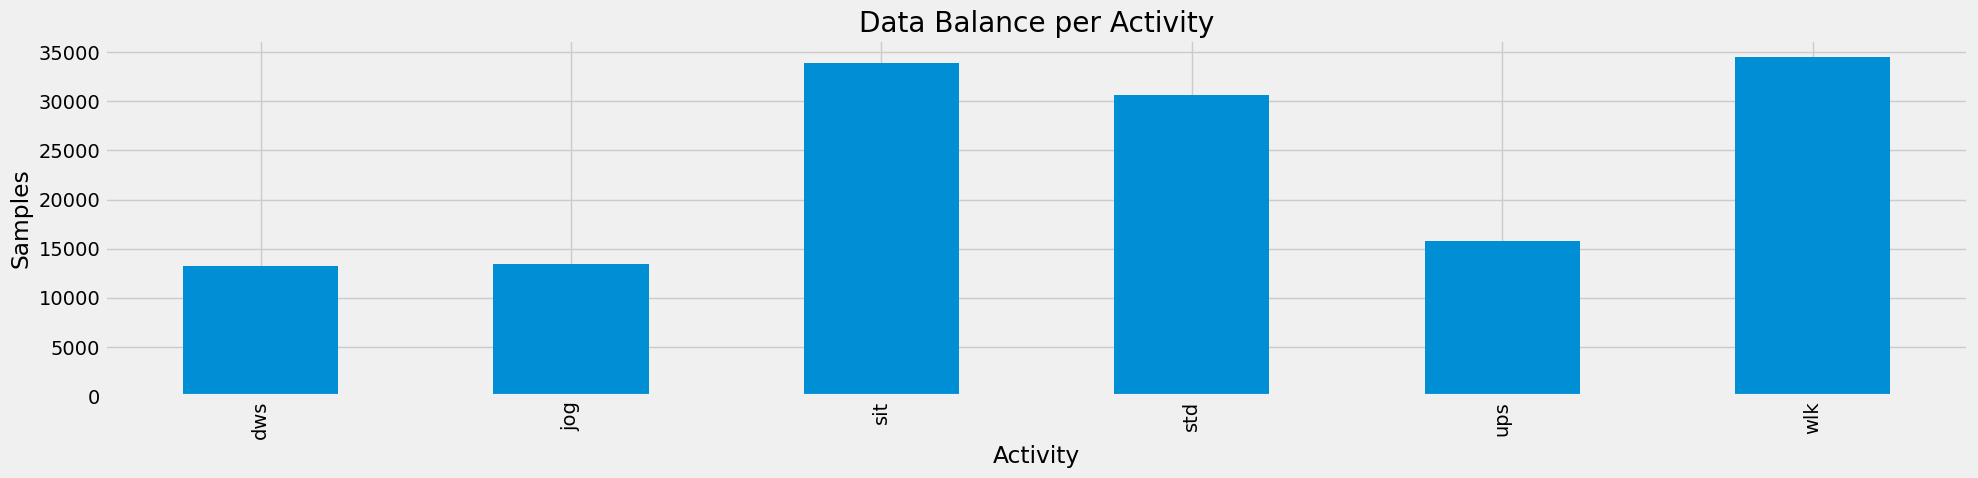

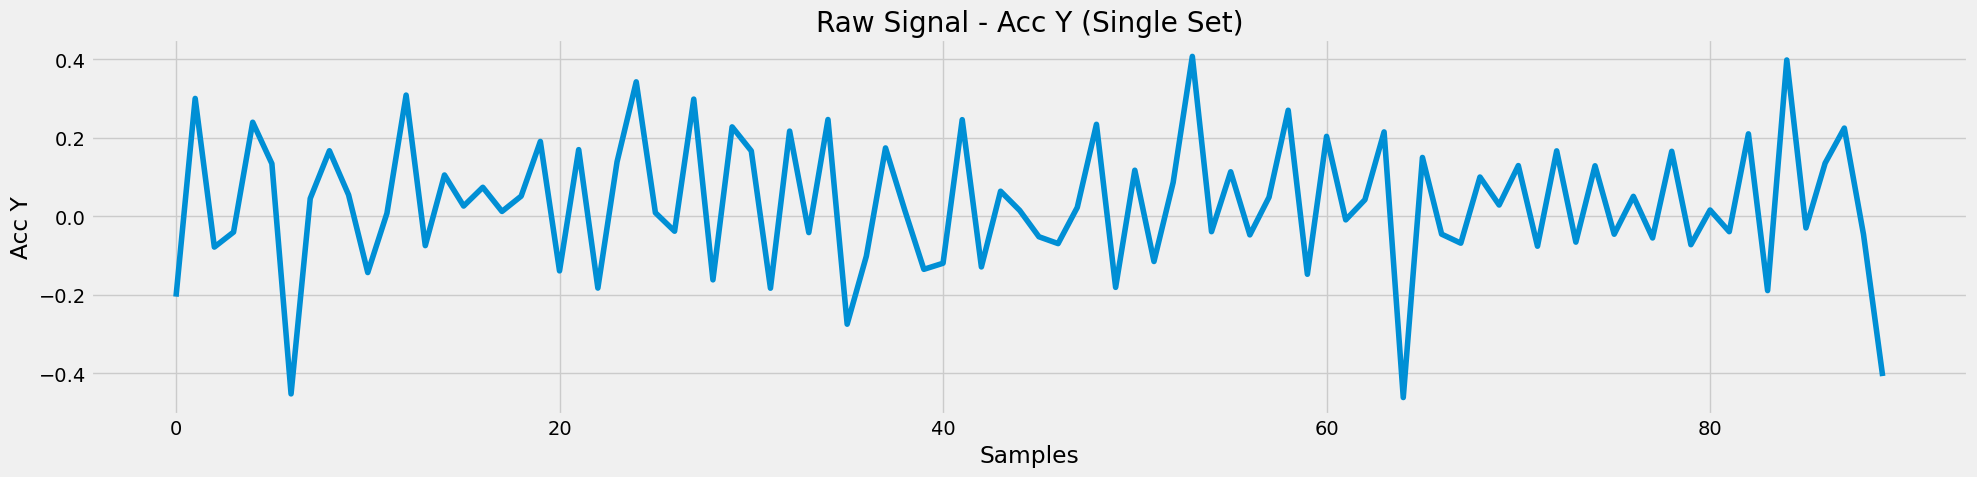

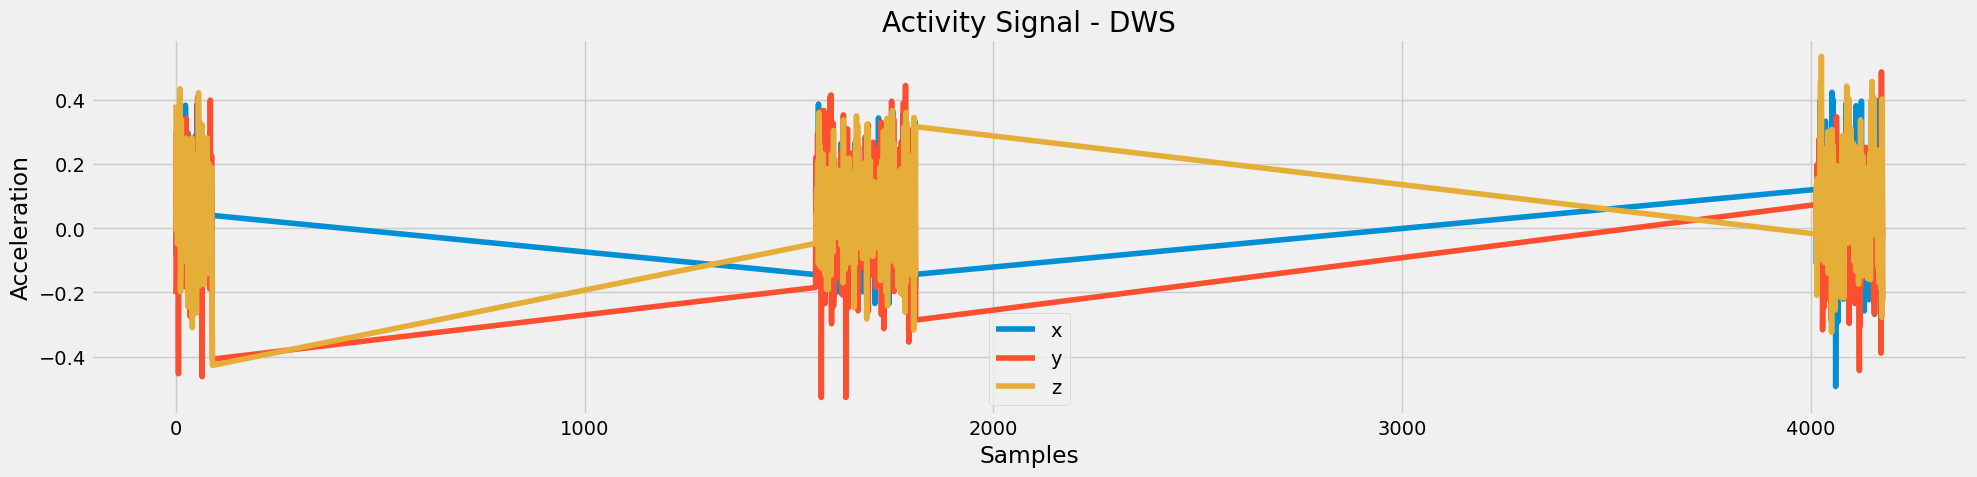

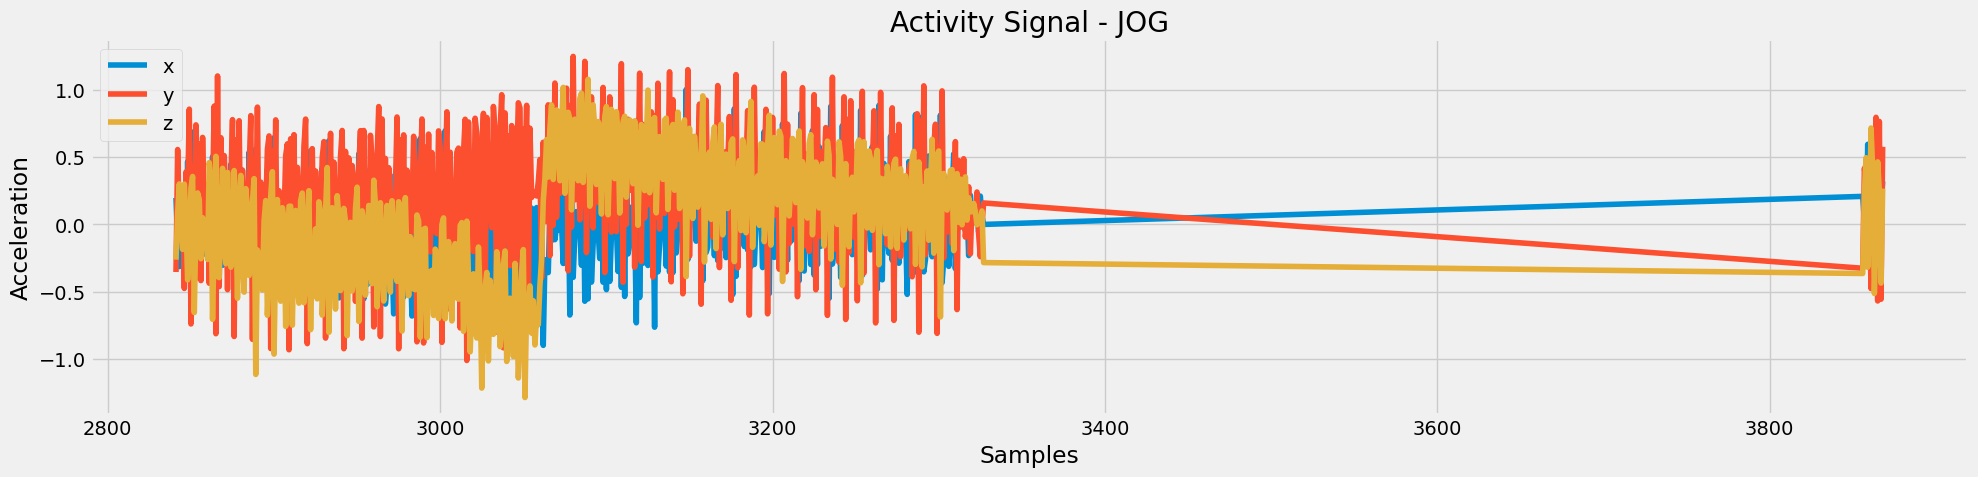

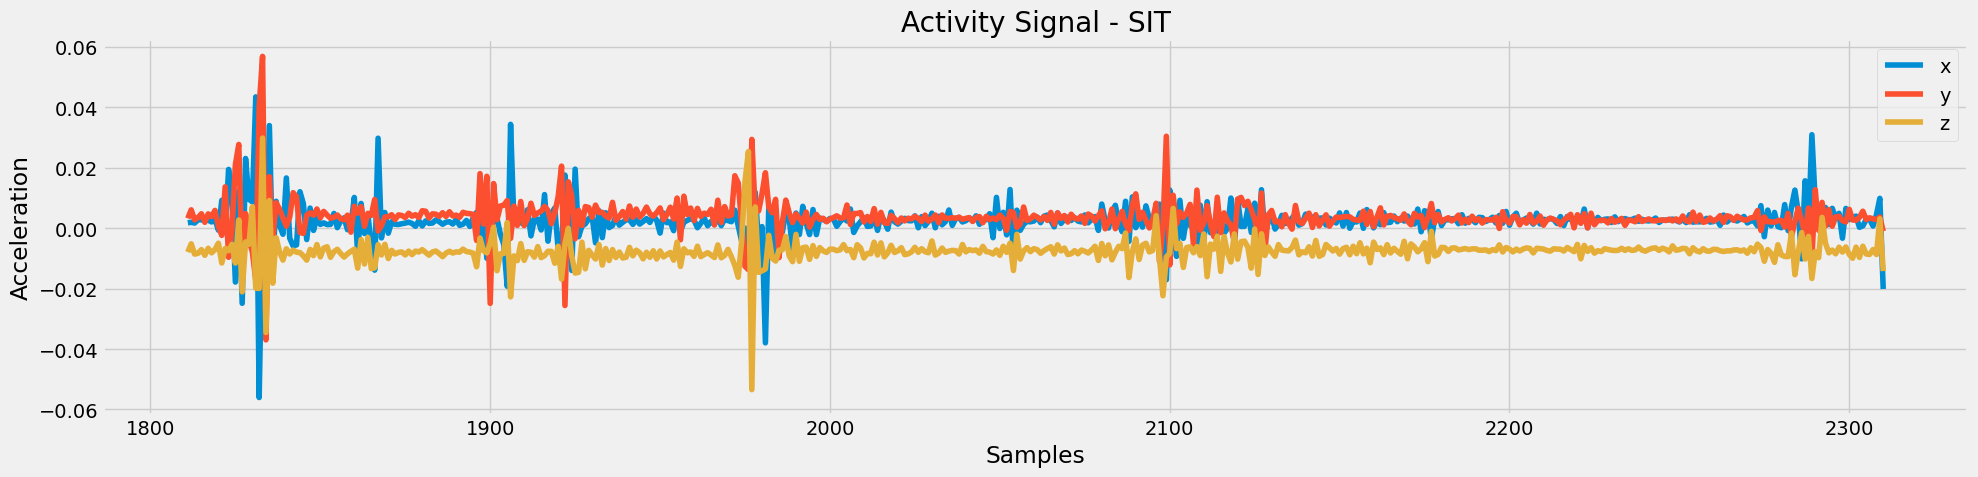

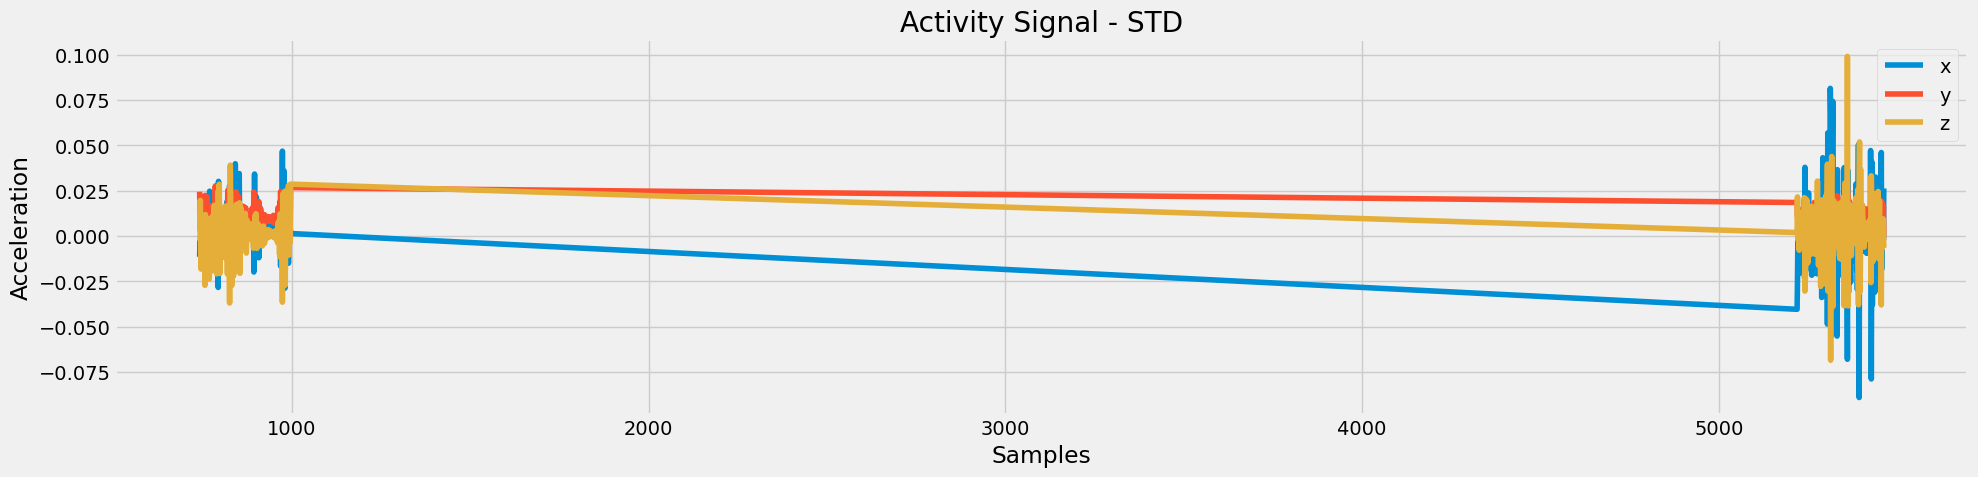

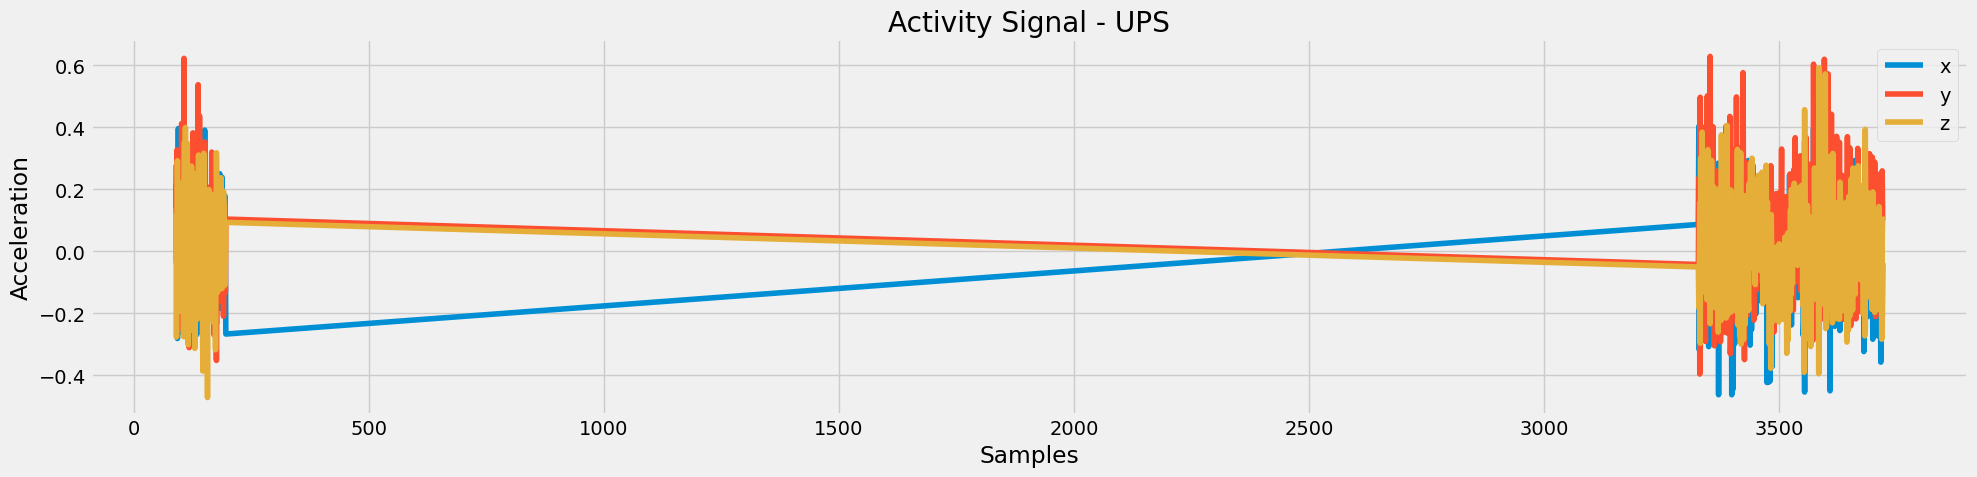

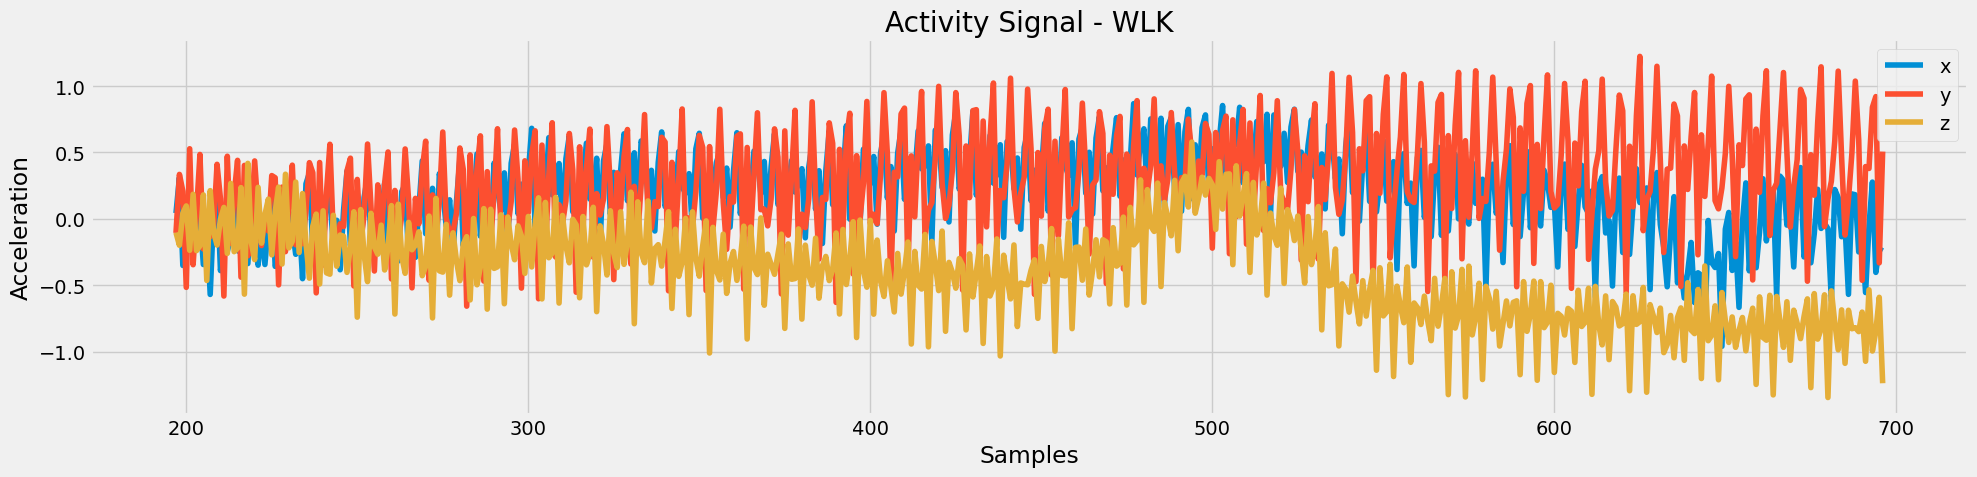

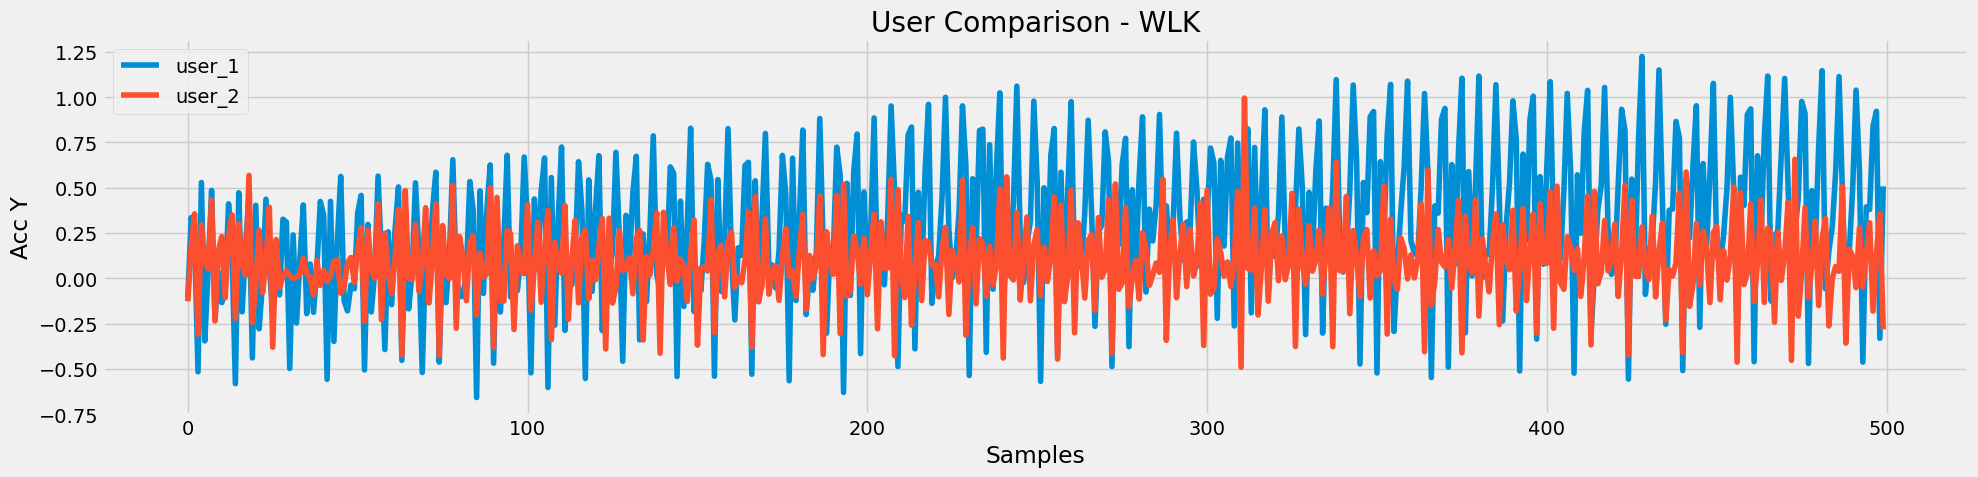

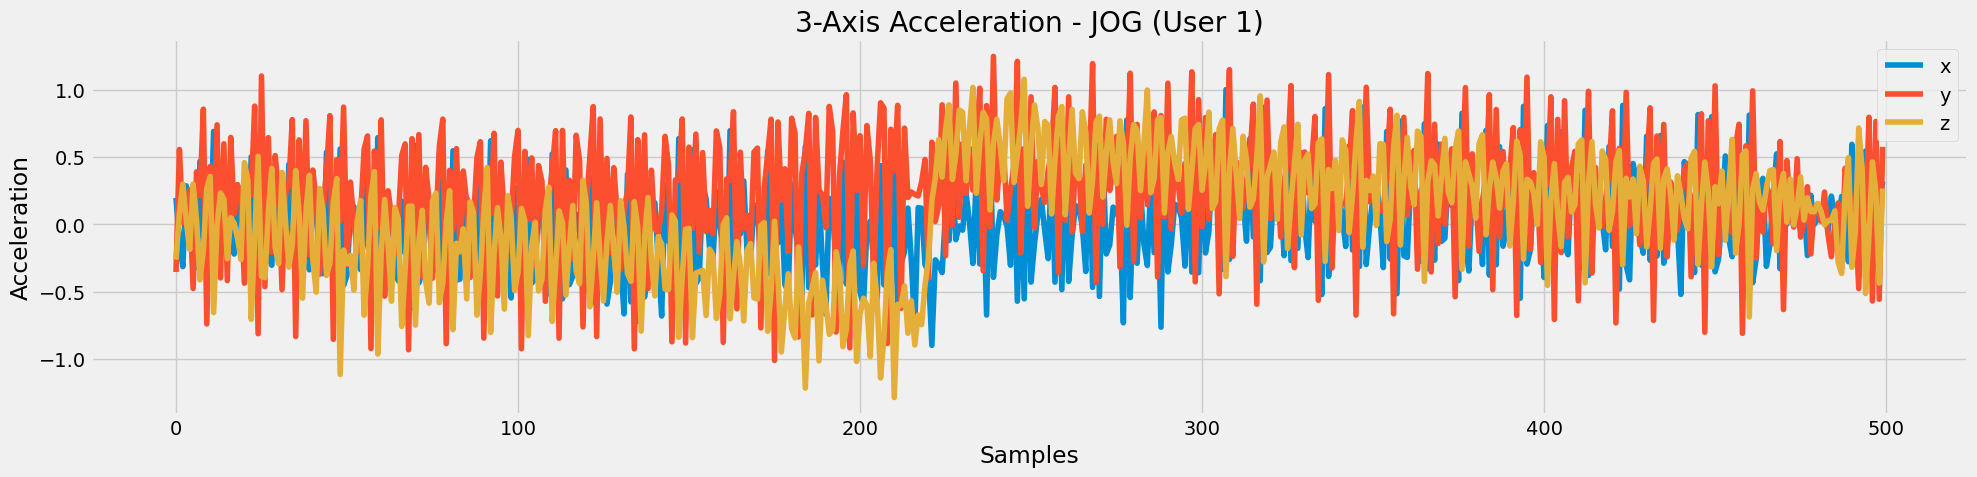

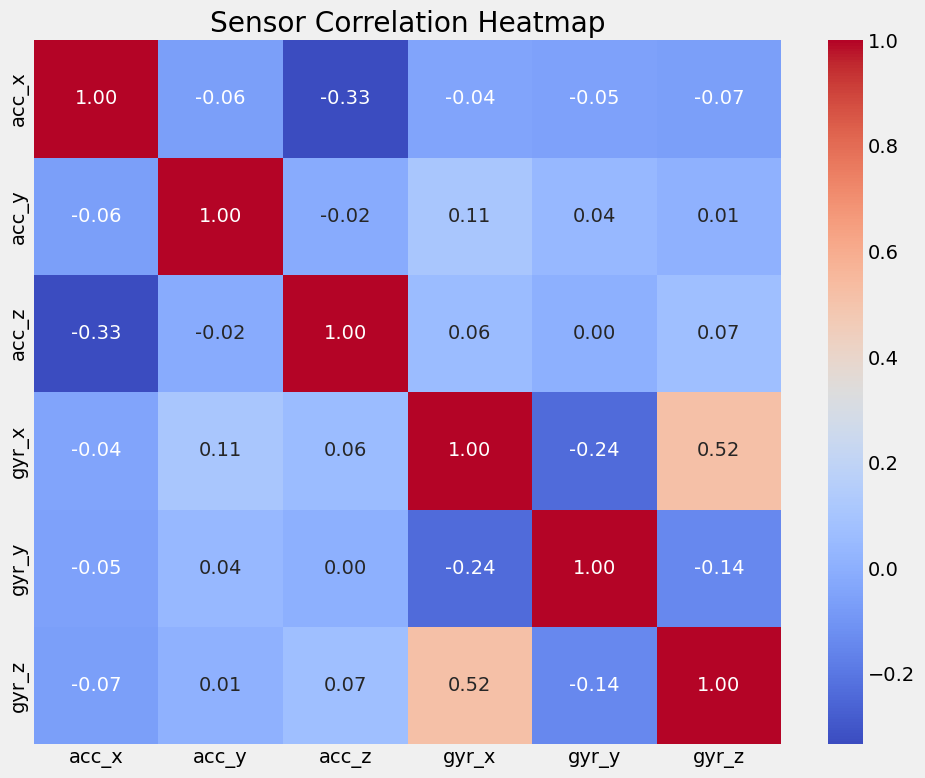

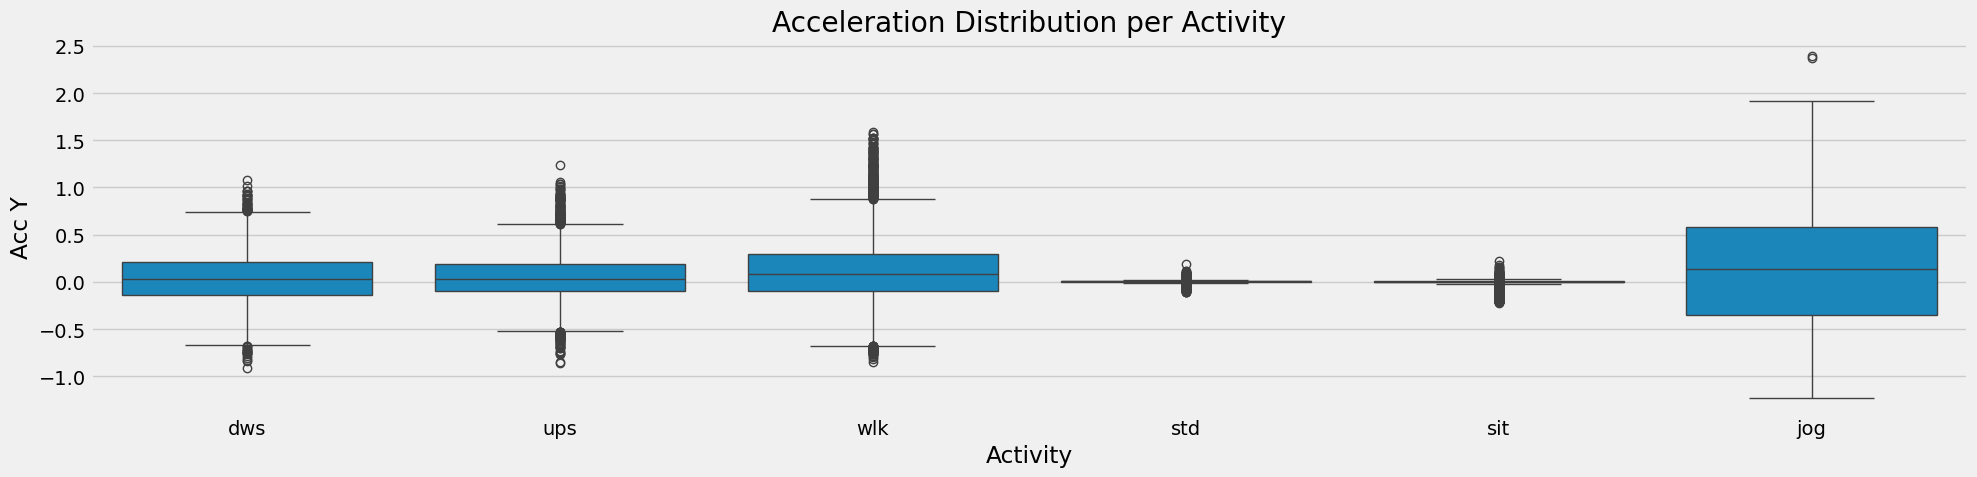

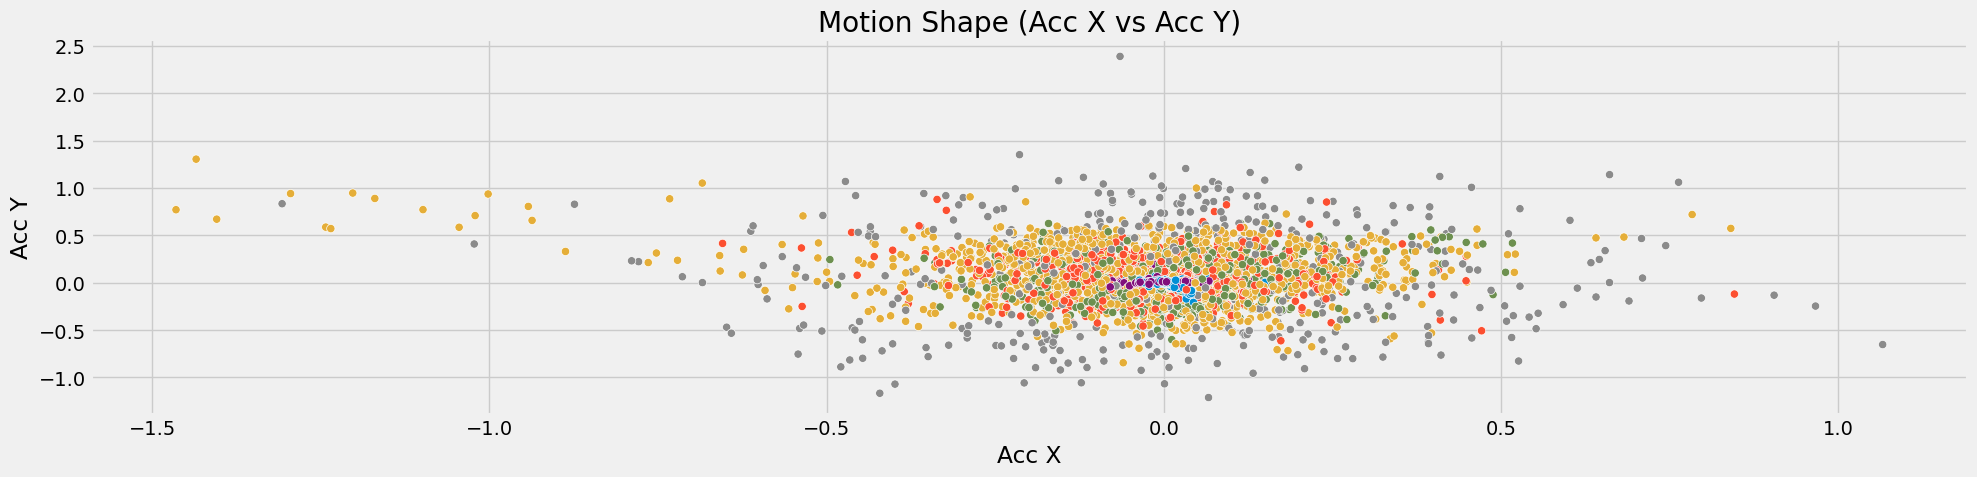

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setup and Load Data

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_pickle("../../data/processed/data_processed.pkl")

os.makedirs("../../reports/figures/", exist_ok=True)

# 2. Data Balance (Check samples per category)

balance = df["category"].value_counts().sort_index()

plt.figure()
balance.plot(kind="bar")
plt.title("Data Balance per Activity")
plt.xlabel("Activity")
plt.ylabel("Samples")
plt.tight_layout()
plt.savefig("../../reports/figures/data_balance.png", dpi=150)
plt.show()

# 3. Explore Single Columns (Raw Signal Inspection)

set_df = df[df["set"] == df["set"].iloc[0]]

plt.figure()
plt.plot(set_df["acc_y"].reset_index(drop=True))
plt.title("Raw Signal - Acc Y (Single Set)")
plt.xlabel("Samples")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/raw_signal_acc_y.png", dpi=150)
plt.show()

# 4. Plot All Activities (Time-series Comparison)

labels = sorted(df["category"].unique())

for label in labels:
    subset = df[df["category"] == label].head(500)

    plt.figure()
    plt.plot(subset["acc_x"], label="x")
    plt.plot(subset["acc_y"], label="y")
    plt.plot(subset["acc_z"], label="z")
    plt.title(f"Activity Signal - {label.upper()}")
    plt.xlabel("Samples")
    plt.ylabel("Acceleration")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/timeseries_{label}.png", dpi=150)
    plt.show()

# 5. Compare Participants (User Differences)

activity = "wlk"
users = df[df["category"] == activity]["user_id"].unique()[:2]

plt.figure()
for u in users:
    u_df = df[(df["category"] == activity) & (df["user_id"] == u)].head(500)
    plt.plot(u_df["acc_y"].reset_index(drop=True), label=f"user_{u}")

plt.title(f"User Comparison - {activity.upper()}")
plt.xlabel("Samples")
plt.ylabel("Acc Y")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../reports/figures/user_comparison_{activity}.png", dpi=150)
plt.show()

# 6. Multiple Axes Plot (3-axis Movement)

label = "jog"
user = df[df["category"] == label]["user_id"].iloc[0]

multi_axis_df = (
    df.query(f"category == '{label}' and user_id == {user}")
    .head(500)
    .reset_index(drop=True)
)

plt.figure()
plt.plot(multi_axis_df["acc_x"], label="x")
plt.plot(multi_axis_df["acc_y"], label="y")
plt.plot(multi_axis_df["acc_z"], label="z")
plt.title(f"3-Axis Acceleration - {label.upper()} (User {user})")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../reports/figures/3axis_{label}_user{user}.png", dpi=150)
plt.show()

# 7. Distribution and Correlation

corr_df = df[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Sensor Correlation Heatmap")
plt.tight_layout()
plt.savefig("../../reports/figures/correlation_heatmap.png", dpi=150)
plt.show()

plt.figure()
sns.boxplot(x="category", y="acc_y", data=df)
plt.title("Acceleration Distribution per Activity")
plt.xlabel("Activity")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/boxplot_acc_y.png", dpi=150)
plt.show()

# 8. Motion Shape (Scatter Plot)

scatter_df = df.sample(5000, random_state=42)

plt.figure()
sns.scatterplot(
    x="acc_x",
    y="acc_y",
    hue="category",
    data=scatter_df,
    legend=False
)
plt.title("Motion Shape (Acc X vs Acc Y)")
plt.xlabel("Acc X")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/scatter_motion_shape.png", dpi=150)
plt.show()

# 9. Mass Export Figures (Acc + Gyro)

test_users = df["user_id"].unique()[:3]

for label in labels:
    for user in test_users:
        subset = df.query(
            f"category == '{label}' and user_id == {user}"
        ).head(500)

        if subset.empty:
            continue

        fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20, 10))

        subset[["acc_x", "acc_y", "acc_z"]].plot(ax=ax[0])
        ax[0].set_title(f"{label.upper()} - User {user}")
        ax[0].set_ylabel("Acceleration")

        subset[["gyr_x", "gyr_y", "gyr_z"]].plot(ax=ax[1])
        ax[1].set_ylabel("Gyroscope")
        ax[1].set_xlabel("Samples")

        plt.tight_layout()
        plt.savefig(f"../../reports/figures/{label}_user{user}.png", dpi=150)
        plt.close(fig)